In [ ]:
# ============================================================
# Klasifikasi Kematangan Pisang (Banana)
# Dataset: 3 Kelas — Mentah / Matang / Terlalu_Matang
# Algoritma: KNN + SVM + Random Forest
# Evaluasi: Akurasi, Presisi, Recall, Specificity, F1, McNemar
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from skimage.feature import local_binary_pattern
from skimage.color import rgb2hsv, rgb2gray
from statsmodels.stats.contingency_tables import mcnemar

# ── Konfigurasi ──
DATASET_PATH = '/content/drive/MyDrive/FruitRipeness/dataset ripenes 250'
IMG_SIZE     = (64, 64)
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# HANYA 3 kelas Banana
CLASSES = [
    'Banana_Matang',
    'Banana_Mentah',
    'Banana_Terlalu_Matang',
]

print('[✓] Library berhasil diimport.')
print(f'[✓] Kelas yang digunakan: {CLASSES}')

Mounted at /content/drive
[✓] Library berhasil diimport.
[✓] Kelas yang digunakan: ['Banana_Matang', 'Banana_Mentah', 'Banana_Terlalu_Matang']


1. DATA AWAL
  Banana_Matang: 250 gambar
  Banana_Mentah: 250 gambar
  Banana_Terlalu_Matang: 250 gambar

Total gambar berhasil dimuat : 750
Gambar gagal dimuat (corrupt): 0

Distribusi Kelas:
Kelas
Banana_Matang            250
Banana_Mentah            250
Banana_Terlalu_Matang    250


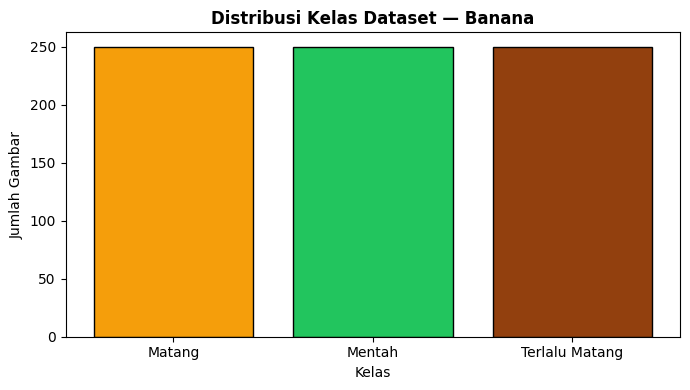

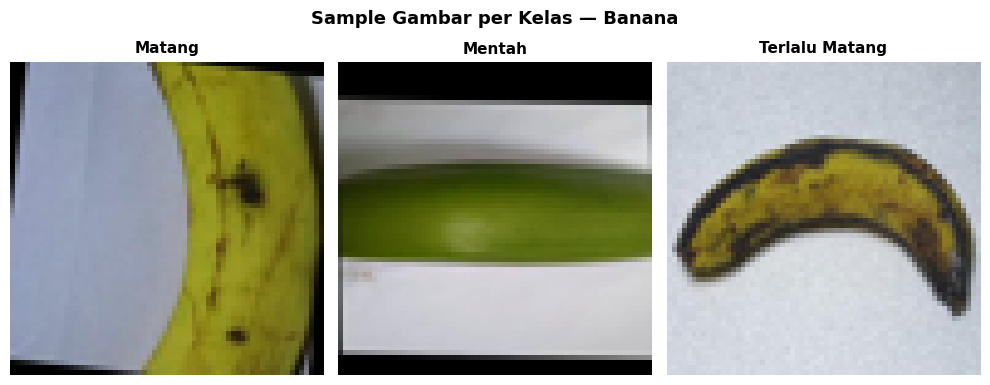

In [ ]:
# ============================================================
# 1. DATA AWAL — Load & Visualisasi
# ============================================================
print('=' * 60)
print('1. DATA AWAL')
print('=' * 60)

def load_images(dataset_path, classes, img_size):
    images, labels, paths = [], [], []
    missing = 0
    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.exists(cls_path):
            print(f'[WARNING] Folder tidak ditemukan: {cls_path}')
            continue
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f'  {cls}: {len(files)} gambar')
        for fname in files:
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath).convert('RGB').resize(img_size)
                images.append(np.array(img))
                labels.append(cls)
                paths.append(fpath)
            except Exception as e:
                print(f'    [SKIP] {fname}: {e}')
                missing += 1
    print(f'\nTotal gambar berhasil dimuat : {len(images)}')
    print(f'Gambar gagal dimuat (corrupt): {missing}')
    return np.array(images), np.array(labels), paths

images, labels, paths = load_images(DATASET_PATH, CLASSES, IMG_SIZE)

label_series = pd.Series(labels, name='Kelas')
dist = label_series.value_counts().reindex(CLASSES)
print('\nDistribusi Kelas:')
print(dist.to_string())

# Visualisasi distribusi
tick_labels = ['Matang', 'Mentah', 'Terlalu Matang']
plt.figure(figsize=(7, 4))
colors_bar = ['#f59e0b', '#22c55e', '#92400e']
plt.bar(tick_labels, dist.values, color=colors_bar, edgecolor='black')
plt.title('Distribusi Kelas Dataset — Banana', fontweight='bold')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kelas')
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150)
plt.show()

# Sample gambar
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, cls in enumerate(CLASSES):
    idx = np.where(labels == cls)[0][0]
    axes[i].imshow(images[idx])
    axes[i].set_title(cls.replace('Banana_','').replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Gambar per Kelas — Banana', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_gambar.png', dpi=150)
plt.show()


2. PREPROCESSING

[Cek Imbalance]
  Kelas terbanyak : 250
  Kelas tersedikit: 250
  Rasio imbalance : 1.00
  → Dataset BALANCED ✓

[✓] Normalisasi pixel [0,255] → [0.0,1.0]

[Cek Outlier] Jumlah potensi outlier: 3
  Index (5 pertama): [115 150 240]
  → Outlier dipertahankan (variasi alami kecerahan buah)


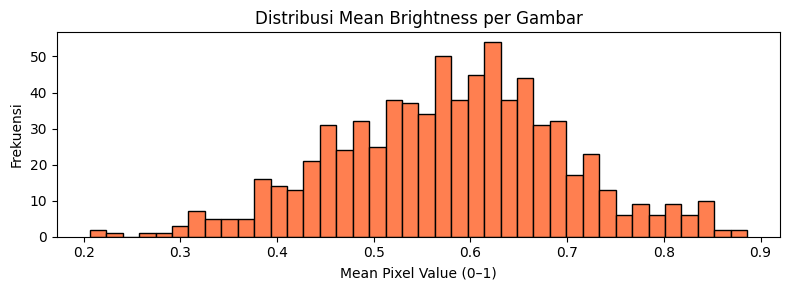

In [ ]:
# ============================================================
# 2. PREPROCESSING
# ============================================================
print('\n' + '=' * 60)
print('2. PREPROCESSING')
print('=' * 60)

# Cek imbalance
counts = dist.values
min_c, max_c = counts.min(), counts.max()
imbalance_ratio = max_c / min_c
print(f'\n[Cek Imbalance]')
print(f'  Kelas terbanyak : {max_c}')
print(f'  Kelas tersedikit: {min_c}')
print(f'  Rasio imbalance : {imbalance_ratio:.2f}')
if imbalance_ratio < 1.5:
    print('  → Dataset BALANCED ✓')
else:
    print('  → Dataset IMBALANCED — pertimbangkan SMOTE.')

# Normalisasi pixel
images_norm = images.astype(np.float32) / 255.0
print('\n[✓] Normalisasi pixel [0,255] → [0.0,1.0]')

# Cek outlier
pixel_means = images_norm.mean(axis=(1,2,3))
Q1, Q3 = np.percentile(pixel_means, 25), np.percentile(pixel_means, 75)
IQR = Q3 - Q1
outliers = np.where((pixel_means < Q1 - 1.5*IQR) | (pixel_means > Q3 + 1.5*IQR))[0]
print(f'\n[Cek Outlier] Jumlah potensi outlier: {len(outliers)}')
if len(outliers) > 0:
    print(f'  Index (5 pertama): {outliers[:5]}')
    print('  → Outlier dipertahankan (variasi alami kecerahan buah)')
else:
    print('  → Tidak ada outlier signifikan ✓')

plt.figure(figsize=(8, 3))
plt.hist(pixel_means, bins=40, color='coral', edgecolor='black')
plt.title('Distribusi Mean Brightness per Gambar')
plt.xlabel('Mean Pixel Value (0–1)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('outlier_check.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================
print('\n' + '=' * 60)
print('3. FEATURE ENGINEERING')
print('=' * 60)
print('Fitur yang diekstrak:')
print('  - Mean & Std RGB per channel   :  6 fitur')
print('  - Histogram HSV (16 bin × 3ch) : 48 fitur')
print('  - LBP Histogram (26 bin)       : 26 fitur')
print('  Total                          : 80 fitur')

def extract_features(images_norm):
    features = []
    for img in images_norm:
        feat = []
        # Mean & Std RGB
        for c in range(3):
            feat.append(img[:,:,c].mean())
            feat.append(img[:,:,c].std())
        # Histogram HSV
        img_hsv = rgb2hsv(img)
        for c in range(3):
            hist, _ = np.histogram(img_hsv[:,:,c], bins=16, range=(0,1))
            feat.extend(hist / (hist.sum() + 1e-6))
        # LBP
        gray       = rgb2gray(img)
        gray_uint8 = (gray * 255).astype(np.uint8)
        lbp        = local_binary_pattern(gray_uint8, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26))
        feat.extend(lbp_hist / (lbp_hist.sum() + 1e-6))
        features.append(feat)
    return np.array(features)

X = extract_features(images_norm)
print(f'\nShape fitur: {X.shape}  → {X.shape[0]} sampel × {X.shape[1]} fitur')

# Label encoding — hanya 3 kelas Banana
le = LabelEncoder()
y  = le.fit_transform(labels)
print(f'Label encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Feature Scaling
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\n[✓] Feature scaling dengan StandardScaler selesai.')


3. FEATURE ENGINEERING
Fitur yang diekstrak:
  - Mean & Std RGB per channel   :  6 fitur
  - Histogram HSV (16 bin × 3ch) : 48 fitur
  - LBP Histogram (26 bin)       : 26 fitur
  Total                          : 80 fitur

Shape fitur: (750, 80)  → 750 sampel × 80 fitur
Label encoded: {np.str_('Banana_Matang'): np.int64(0), np.str_('Banana_Mentah'): np.int64(1), np.str_('Banana_Terlalu_Matang'): np.int64(2)}

[✓] Feature scaling dengan StandardScaler selesai.


In [ ]:
# ============================================================
# 4. SPLIT DATA
# ============================================================
print('\n' + '=' * 60)
print('4. SPLIT DATA (80% Train / 20% Test)')
print('=' * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y
)
print(f'  Train: {X_train.shape[0]} sampel')
print(f'  Test : {X_test.shape[0]} sampel')
print(f'  Stratify: ya (proporsi kelas terjaga)')


4. SPLIT DATA (80% Train / 20% Test)
  Train: 600 sampel
  Test : 150 sampel
  Stratify: ya (proporsi kelas terjaga)



5. MODEL: K-Nearest Neighbor (KNN)
K terbaik (5-Fold CV): K=2  (Akurasi CV: 0.9383)


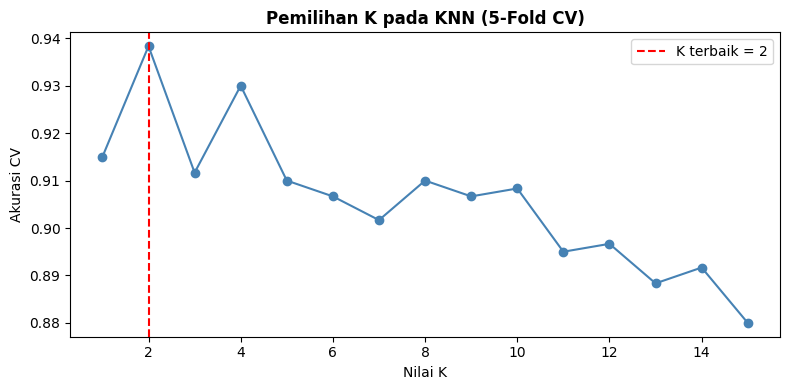

[✓] KNN Training selesai. Akurasi Test: 0.9667


In [ ]:
# ============================================================
# 5. MODEL — KNN
# ============================================================
print('\n' + '=' * 60)
print('5. MODEL: K-Nearest Neighbor (KNN)')
print('=' * 60)

k_range  = range(1, 16)
k_scores = []
for k in k_range:
    cv = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, metric='euclidean'),
        X_train, y_train, cv=5, scoring='accuracy'
    )
    k_scores.append(cv.mean())

best_k = k_range[np.argmax(k_scores)]
print(f'K terbaik (5-Fold CV): K={best_k}  (Akurasi CV: {max(k_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, 'o-', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'K terbaik = {best_k}')
plt.title('Pemilihan K pada KNN (5-Fold CV)', fontweight='bold')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi CV')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150)
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(f'[✓] KNN Training selesai. Akurasi Test: {accuracy_score(y_test, y_pred_knn):.4f}')

In [ ]:
# ============================================================
# 6. MODEL — SVM
# ============================================================
print('\n' + '=' * 60)
print('6. MODEL: Support Vector Machine (SVM)')
print('=' * 60)

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True,
          decision_function_shape='ovr', random_state=RANDOM_STATE)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(f'[✓] SVM Training selesai. Akurasi Test: {accuracy_score(y_test, y_pred_svm):.4f}')
print('    kernel=RBF, C=10, gamma=scale, probability=True')


6. MODEL: Support Vector Machine (SVM)
[✓] SVM Training selesai. Akurasi Test: 0.9733
    kernel=RBF, C=10, gamma=scale, probability=True



7. MODEL: Random Forest (RF)
[✓] RF Training selesai. Akurasi Test: 0.9800
    n_estimators=200


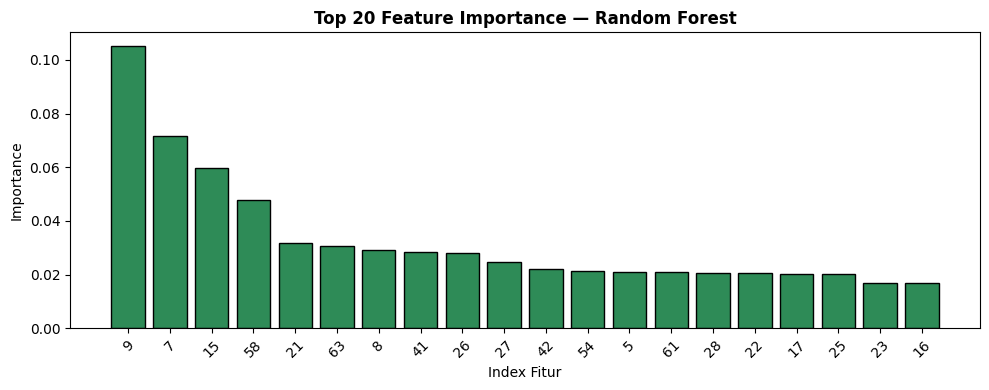

In [ ]:
# ============================================================
# 7. MODEL — RANDOM FOREST
# ============================================================
print('\n' + '=' * 60)
print('7. MODEL: Random Forest (RF)')
print('=' * 60)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f'[✓] RF Training selesai. Akurasi Test: {accuracy_score(y_test, y_pred_rf):.4f}')
print('    n_estimators=200')

# Feature Importance
importances = rf.feature_importances_
top20_idx   = importances.argsort()[::-1][:20]
plt.figure(figsize=(10, 4))
plt.bar(range(20), importances[top20_idx], color='seagreen', edgecolor='black')
plt.xticks(range(20), top20_idx, rotation=45)
plt.title('Top 20 Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Index Fitur')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# 8. EVALUASI — 3 MODEL
# ============================================================
print('\n' + '=' * 60)
print('8. EVALUASI MODEL')
print('=' * 60)

def compute_metrics(y_true, y_pred, model_name, classes):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    spec_list = []
    for i in range(len(classes)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        spec_list.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    specificity = np.mean(spec_list)

    print(f"\n{'─'*45}")
    print(f'  {model_name}')
    print(f"{'─'*45}")
    print(f'  Akurasi    : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Presisi    : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  Specificity: {specificity:.4f}')
    print(f'  F1-Measure : {f1:.4f}')
    short = [c.replace('Banana_','') for c in classes]
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=short, zero_division=0))
    return {'Model': model_name, 'Akurasi': acc, 'Presisi': prec,
            'Recall': rec, 'Specificity': specificity, 'F1-Measure': f1}

m_knn = compute_metrics(y_test, y_pred_knn, f'KNN (K={best_k})', le.classes_)
m_svm = compute_metrics(y_test, y_pred_svm, 'SVM (RBF)',          le.classes_)
m_rf  = compute_metrics(y_test, y_pred_rf,  'Random Forest',      le.classes_)

df_metrics = pd.DataFrame([m_knn, m_svm, m_rf]).set_index('Model')
print('\n' + '=' * 60)
print('PERBANDINGAN KETIGA MODEL')
print('=' * 60)
print(df_metrics.round(4).to_string())
best_model = df_metrics['Akurasi'].idxmax()
print(f'\n[★] Model terbaik: {best_model} ({df_metrics.loc[best_model,"Akurasi"]*100:.2f}%)')


8. EVALUASI MODEL

─────────────────────────────────────────────
  KNN (K=2)
─────────────────────────────────────────────
  Akurasi    : 0.9667  (96.67%)
  Presisi    : 0.9672
  Recall     : 0.9667
  Specificity: 0.9833
  F1-Measure : 0.9667

  Classification Report:
                precision    recall  f1-score   support

        Matang       0.94      0.98      0.96        50
        Mentah       0.98      0.98      0.98        50
Terlalu_Matang       0.98      0.94      0.96        50

      accuracy                           0.97       150
     macro avg       0.97      0.97      0.97       150
  weighted avg       0.97      0.97      0.97       150


─────────────────────────────────────────────
  SVM (RBF)
─────────────────────────────────────────────
  Akurasi    : 0.9733  (97.33%)
  Presisi    : 0.9735
  Recall     : 0.9733
  Specificity: 0.9867
  F1-Measure : 0.9733

  Classification Report:
                precision    recall  f1-score   support

        Matang       0.96  

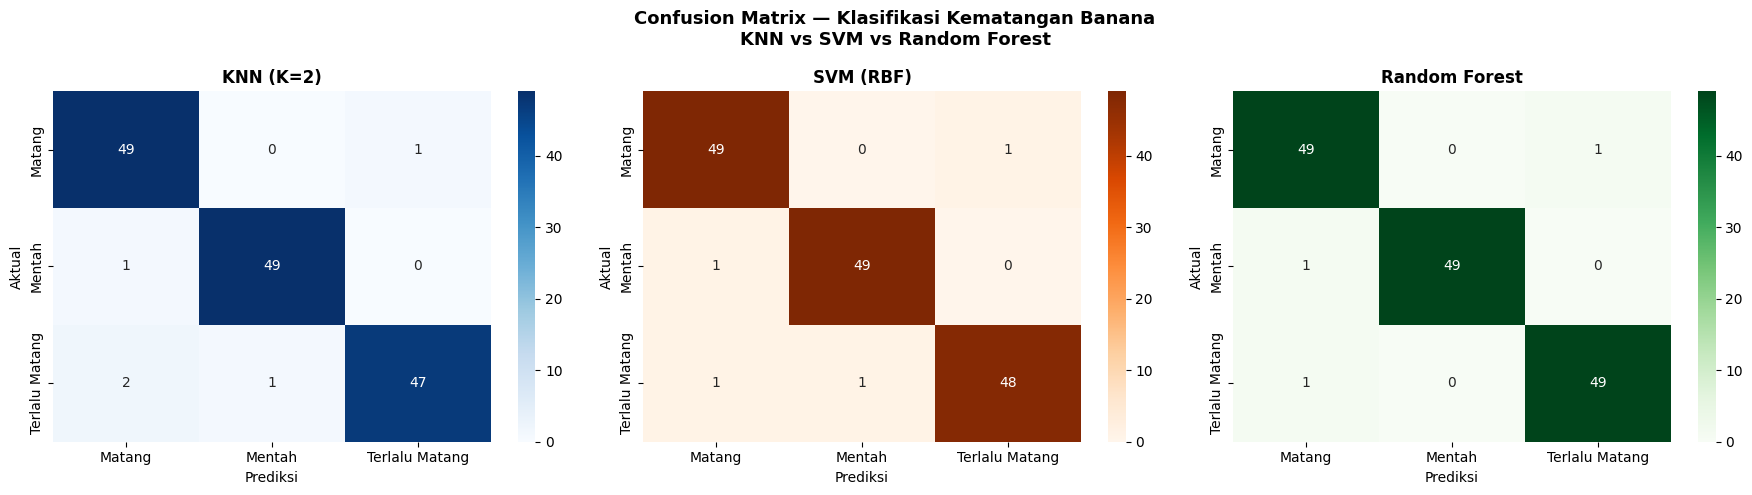

In [ ]:
# ============================================================
# 9. CONFUSION MATRIX — 3 MODEL
# ============================================================
short_labels = ['Matang', 'Mentah', 'Terlalu Matang']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_preds  = [y_pred_knn, y_pred_svm, y_pred_rf]
model_titles = [f'KNN (K={best_k})', 'SVM (RBF)', 'Random Forest']
cmaps        = ['Blues', 'Oranges', 'Greens']

for ax, yp, title, cmap in zip(axes, model_preds, model_titles, cmaps):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=short_labels, yticklabels=short_labels, ax=ax)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Klasifikasi Kematangan Banana\nKNN vs SVM vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_3model.png', dpi=150, bbox_inches='tight')
plt.show()

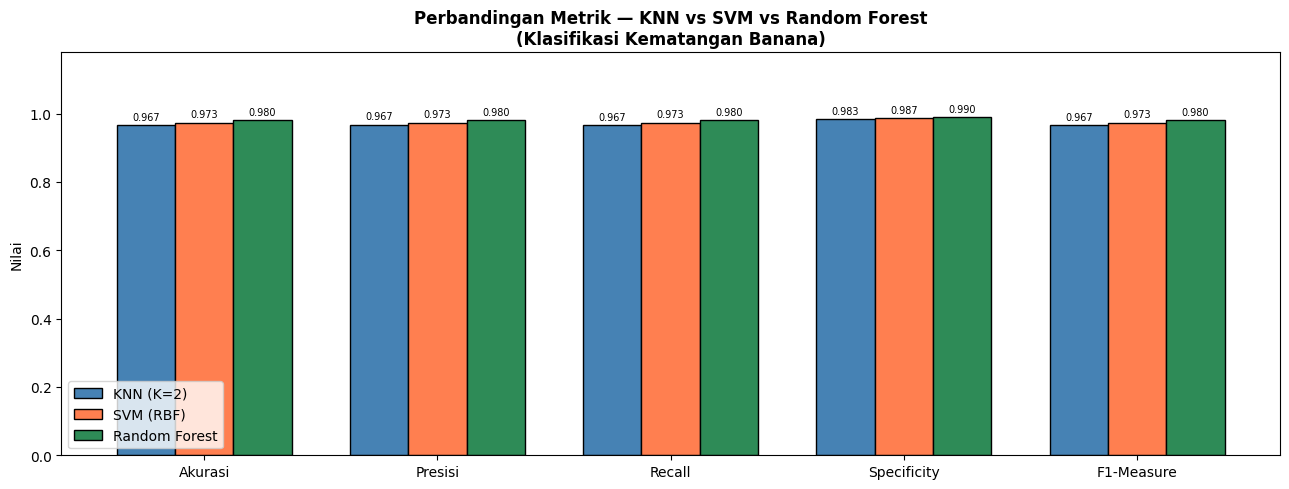

In [ ]:
# ============================================================
# 10. PERBANDINGAN METRIK — BAR CHART
# ============================================================
metrics_cols = ['Akurasi', 'Presisi', 'Recall', 'Specificity', 'F1-Measure']
df_plot = df_metrics[metrics_cols]
x     = np.arange(len(metrics_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width, df_plot.iloc[0], width, label=df_plot.index[0], color='steelblue', edgecolor='black')
bars2 = ax.bar(x,          df_plot.iloc[1], width, label=df_plot.index[1], color='coral',     edgecolor='black')
bars3 = ax.bar(x + width,  df_plot.iloc[2], width, label=df_plot.index[2], color='seagreen',  edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Metrik — KNN vs SVM vs Random Forest\n(Klasifikasi Kematangan Banana)',
             fontweight='bold')
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('perbandingan_metrik.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# 11. MCNEMAR'S TEST
# ============================================================
print('\n' + '=' * 60)
print("11. MCNEMAR'S TEST (Hypothesis Testing)")
print('=' * 60)
print('H0: Kedua model memiliki akurasi yang SAMA')
print('H1: Kedua model memiliki akurasi yang BERBEDA')
print('Alpha (α) = 0.05')

def mcnemar_test(y_true, y_pred1, y_pred2, name1, name2, alpha=0.05):
    correct1 = (y_pred1 == y_true)
    correct2 = (y_pred2 == y_true)
    a = int(np.sum( correct1 &  correct2))
    b = int(np.sum( correct1 & ~correct2))
    c = int(np.sum(~correct1 &  correct2))
    d = int(np.sum(~correct1 & ~correct2))
    conti  = [[a, b], [c, d]]
    exact  = (b + c) < 25
    result = mcnemar(conti, exact=exact)

    print(f"\n{'─'*50}")
    print(f'  {name1} vs {name2}')
    print(f"{'─'*50}")
    print(f'  Tabel Contingency:')
    print(f'  ┌──────────────┬──────────────┬──────────────┐')
    print(f'  │              │ {name2} Benar │ {name2} Salah│')
    print(f'  ├──────────────┼──────────────┼──────────────┤')
    print(f'  │ {name1} Benar│    {a:5d}     │    {b:5d}     │')
    print(f'  │ {name1} Salah│    {c:5d}     │    {d:5d}     │')
    print(f'  └──────────────┴──────────────┴──────────────┘')
    print(f'  Statistic = {result.statistic:.4f}')
    print(f'  p-value   = {result.pvalue:.4f}  (exact={exact})')
    kes = 'BERBEDA signifikan' if result.pvalue <= alpha else 'TIDAK berbeda signifikan'
    tanda = '≤' if result.pvalue <= alpha else '>'
    print(f'  → p={result.pvalue:.4f} {tanda} α={alpha} → H0 {"DITOLAK" if result.pvalue<=alpha else "GAGAL DITOLAK"}')
    print(f'  → Kesimpulan: {name1} dan {name2} {kes}')
    return result

r1 = mcnemar_test(y_test, y_pred_knn, y_pred_svm, f'KNN(K={best_k})', 'SVM')
r2 = mcnemar_test(y_test, y_pred_knn, y_pred_rf,  f'KNN(K={best_k})', 'RF')
r3 = mcnemar_test(y_test, y_pred_svm, y_pred_rf,  'SVM',              'RF')

print('\n' + '=' * 60)
print("RINGKASAN MCNEMAR'S TEST")
print('=' * 60)
summary = pd.DataFrame([
    {'Perbandingan': 'KNN vs SVM', 'p-value': round(r1.pvalue,4),
     'Kesimpulan': 'Berbeda signifikan' if r1.pvalue<=0.05 else 'Tidak berbeda signifikan'},
    {'Perbandingan': 'KNN vs RF',  'p-value': round(r2.pvalue,4),
     'Kesimpulan': 'Berbeda signifikan' if r2.pvalue<=0.05 else 'Tidak berbeda signifikan'},
    {'Perbandingan': 'SVM vs RF',  'p-value': round(r3.pvalue,4),
     'Kesimpulan': 'Berbeda signifikan' if r3.pvalue<=0.05 else 'Tidak berbeda signifikan'},
])
print(summary.to_string(index=False))


11. MCNEMAR'S TEST (Hypothesis Testing)
H0: Kedua model memiliki akurasi yang SAMA
H1: Kedua model memiliki akurasi yang BERBEDA
Alpha (α) = 0.05

──────────────────────────────────────────────────
  KNN(K=2) vs SVM
──────────────────────────────────────────────────
  Tabel Contingency:
  ┌──────────────┬──────────────┬──────────────┐
  │              │ SVM Benar │ SVM Salah│
  ├──────────────┼──────────────┼──────────────┤
  │ KNN(K=2) Benar│      143     │        2     │
  │ KNN(K=2) Salah│        3     │        2     │
  └──────────────┴──────────────┴──────────────┘
  Statistic = 2.0000
  p-value   = 1.0000  (exact=True)
  → p=1.0000 > α=0.05 → H0 GAGAL DITOLAK
  → Kesimpulan: KNN(K=2) dan SVM TIDAK berbeda signifikan

──────────────────────────────────────────────────
  KNN(K=2) vs RF
──────────────────────────────────────────────────
  Tabel Contingency:
  ┌──────────────┬──────────────┬──────────────┐
  │              │ RF Benar │ RF Salah│
  ├──────────────┼──────────────┼────

In [ ]:
# ============================================================
# 12. KESIMPULAN
# ============================================================
print('\n' + '=' * 60)
print('12. KESIMPULAN')
print('=' * 60)
print('\nPerbandingan Performa Ketiga Model:')
print(df_metrics.round(4).to_string())

best_model = df_metrics['Akurasi'].idxmax()
best_acc   = df_metrics.loc[best_model, 'Akurasi']
best_f1    = df_metrics.loc[best_model, 'F1-Measure']

print(f"""
Kesimpulan:
1. Dataset yang digunakan adalah gambar kematangan Banana
   dengan 3 kelas: Mentah, Matang, dan Terlalu Matang.
   Masing-masing kelas terdiri dari 250 gambar.

2. Tiga algoritma diuji: KNN (K={best_k}), SVM (RBF), dan Random Forest.

3. Model terbaik adalah {best_model}:
   - Akurasi    : {best_acc*100:.2f}%
   - F1-Measure : {best_f1:.4f}

4. McNemar's Test digunakan untuk membuktikan secara statistik
   apakah perbedaan akurasi antar model signifikan (α=0.05).

5. Fitur yang digunakan: 80 fitur (RGB mean/std + HSV histogram + LBP)
   mampu membedakan tahap kematangan pisang berdasarkan
   informasi warna dan tekstur permukaan.
""")


12. KESIMPULAN

Perbandingan Performa Ketiga Model:
               Akurasi  Presisi  Recall  Specificity  F1-Measure
Model                                                           
KNN (K=2)       0.9667   0.9672  0.9667       0.9833      0.9667
SVM (RBF)       0.9733   0.9735  0.9733       0.9867      0.9733
Random Forest   0.9800   0.9803  0.9800       0.9900      0.9801

Kesimpulan:
1. Dataset yang digunakan adalah gambar kematangan Banana
   dengan 3 kelas: Mentah, Matang, dan Terlalu Matang.
   Masing-masing kelas terdiri dari 250 gambar.

2. Tiga algoritma diuji: KNN (K=2), SVM (RBF), dan Random Forest.

3. Model terbaik adalah Random Forest:
   - Akurasi    : 98.00%
   - F1-Measure : 0.9801

4. McNemar's Test digunakan untuk membuktikan secara statistik
   apakah perbedaan akurasi antar model signifikan (α=0.05).

5. Fitur yang digunakan: 80 fitur (RGB mean/std + HSV histogram + LBP)
   mampu membedakan tahap kematangan pisang berdasarkan
   informasi warna dan tekstur permuka

In [ ]:
# ============================================================
# 13. SIMPAN & DOWNLOAD MODEL
# ============================================================
import pickle, zipfile
from google.colab import files

os.makedirs('models', exist_ok=True)

with open('models/model_rf.pkl',       'wb') as f: pickle.dump(rf,      f)
with open('models/model_svm.pkl',      'wb') as f: pickle.dump(svm,     f)
with open('models/model_knn.pkl',      'wb') as f: pickle.dump(knn,     f)
with open('models/scaler.pkl',         'wb') as f: pickle.dump(scaler,  f)
with open('models/label_encoder.pkl',  'wb') as f: pickle.dump(le,      f)
with open('models/best_k.pkl',         'wb') as f: pickle.dump(best_k,  f)

pkl_files = ['model_rf.pkl','model_svm.pkl','model_knn.pkl',
             'scaler.pkl','label_encoder.pkl','best_k.pkl']

with zipfile.ZipFile('models_banana.zip', 'w') as zf:
    for fname in pkl_files:
        zf.write(f'models/{fname}', fname)
        size = os.path.getsize(f'models/{fname}') / 1024
        print(f'  [✓] {fname:25s} {size:7.0f} KB')

print('\n[✓] Semua model berhasil disimpan!')
files.download('models_banana.zip')
print('[✓] Download models_banana.zip selesai!')
print('\nLangkah selanjutnya:')
print('  1. Ekstrak models_banana.zip → letakkan semua .pkl ke folder models/')
print('  2. Ganti app.py dan index.html dengan versi baru')
print('  3. Jalankan: python app.py')

  [✓] model_rf.pkl                 1682 KB
  [✓] model_svm.pkl                 171 KB
  [✓] model_knn.pkl                 380 KB
  [✓] scaler.pkl                      2 KB
  [✓] label_encoder.pkl               0 KB
  [✓] best_k.pkl                      0 KB

[✓] Semua model berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[✓] Download models_banana.zip selesai!

Langkah selanjutnya:
  1. Ekstrak models_banana.zip → letakkan semua .pkl ke folder models/
  2. Ganti app.py dan index.html dengan versi baru
  3. Jalankan: python app.py
